# Medical Question Answering — Projet académique

Ce notebook implémente un système de **Medical Q&A** en comparant plusieurs stratégies :
- **Stratégie 1** : Zero-shot (Direct + Prompt Engineering)
- **Stratégie 2** : RAG (Retrieval Augmented Generation)
- **Stratégie 3** : Fine-tuning QLoRA

**Environnement** : Google Colab (GPU T4), PyTorch, Transformers, PEFT, TRL, Evaluate, LangChain.

# Partie proche du cours

---
## Étape 1 : Installation et préparation

On installe les dépendances, charge le dataset **medalpaca/medical_meadow_medical_flashcards**, l’analyse succinctement et crée un split **90 % train / 10 % test** (pas de split fourni par le dataset).

### 1.1 Installation des dépendances

Exécuter cette cellule en premier (idéalement avec **GPU T4** activé dans Colab : *Runtime > Change runtime type*).

In [2]:
# Installation des bibliothèques pour Colab (GPU T4)
!pip install -q torch transformers accelerate bitsandbytes
!pip install -q peft trl datasets
!pip install -q evaluate rouge_score sacrebleu
!pip install -q langchain langchain-community langchain-core
!pip install -q sentence-transformers
# FAISS : faiss-gpu sur Colab avec GPU, sinon faiss-cpu
!pip install -q faiss-cpu
# Pour llm as judge
!pip install -q openai

print("Installation terminée.")

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
s3fs 2026.1.0 requires fsspec==2026.1.0, but you have fsspec 2025.10.0 which is incompatible.
Installation terminée.


In [ ]:
# # Installation des bibliothèques pour Colab (GPU T4)
# !pip install -q "torch>=2.0" "transformers>=4.36" "accelerate>=0.25" "bitsandbytes>=0.41"
# !pip install -q "peft>=0.7" "trl>=0.7" "datasets>=2.14"
# !pip install -q "evaluate>=0.4" "rouge_score>=0.1" "sacrebleu"
# !pip install -q "langchain>=0.1" "langchain-community>=0.0.10" "langchain-core"
# !pip install -q "sentence-transformers>=2.2"
# # FAISS : faiss-gpu sur Colab avec GPU, sinon faiss-cpu
# !pip install -q faiss-cpu

# print("Installation terminée.")

### 1.2 Imports et configuration

In [ ]:
import os
import gc
import torch
from datasets import load_dataset
import pandas as pd
from huggingface_hub import login

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
if device == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

login(token=) # Put your login token here

/opt/python/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
GPU: NVIDIA A2


### 1.3 Chargement et analyse du dataset

Le dataset fournit des paires **Question / Answer** (colonnes `input` et `output`). Il n’y a pas de split ; on utilisera `train_test_split` pour créer train (90 %) et test (10 %).

In [2]:
DATASET_NAME = "medalpaca/medical_meadow_medical_flashcards"

dataset = load_dataset(DATASET_NAME)
print("Clés:", dataset.keys())
print("Structure:", dataset)

# Le dataset a souvent une clé "train"
if "train" in dataset:
    full = dataset["train"]
else:
    full = dataset[list(dataset.keys())[0]]

print("\nColonnes:", full.column_names)
print("Nombre d'exemples:", len(full))

Clés: dict_keys(['train'])
Structure: DatasetDict({
    train: Dataset({
        features: ['input', 'output', 'instruction'],
        num_rows: 33955
    })
})

Colonnes: ['input', 'output', 'instruction']
Nombre d'exemples: 33955


### 1.4 Exemples et normalisation des colonnes

On s’assure d’avoir des champs `question` et `answer` (en mappant `input` → `question`, `output` → `answer` si nécessaire).

In [3]:
# Normalisation : input -> question, output -> answer (medalpaca)
data = full.rename_columns({"input": "question", "output": "answer"})
data = data.remove_columns([c for c in data.column_names if c not in ["question", "answer"]])

# 2–3 exemples
for i in range(min(3, len(data))):
    r = data[i]
    print(f"--- Exemple {i+1} ---\nQuestion: {(r['question'][:180] + '...') if len(r['question']) > 180 else r['question']}\nAnswer: {(r['answer'][:180] + '...') if len(r['answer']) > 180 else r['answer']}\n")

--- Exemple 1 ---
Question: What is the relationship between very low Mg2+ levels, PTH levels, and Ca2+ levels?
Answer: Very low Mg2+ levels correspond to low PTH levels which in turn results in low Ca2+ levels.

--- Exemple 2 ---
Question: What leads to genitourinary syndrome of menopause (atrophic vaginitis)?
Answer: Low estradiol production leads to genitourinary syndrome of menopause (atrophic vaginitis).

--- Exemple 3 ---
Question: What does low REM sleep latency and experiencing hallucinations/sleep paralysis suggest?
Answer: Low REM sleep latency and experiencing hallucinations/sleep paralysis suggests narcolepsy.



### 1.5 Split 90 % train / 10 % test

Split aléatoire avec `train_test_split` (seed pour reproductibilité). Le **test** servira à l’évaluation des stratégies.

In [4]:
# 90 % train, 10 % test (seed=42)
splits = data.train_test_split(test_size=0.10, seed=42)
train_data = splits["train"]
test_data = splits["test"]
print(f"Train: {len(train_data)} | Test: {len(test_data)}")

Train: 30559 | Test: 3396


---
## Étape 2 : Stratégie 1 — Zero-shot et Prompt Engineering

On charge un **modèle léger en 4-bit** (TinyLlama ou Zephyr) et on définit `generate_answer(question, strategy="direct"|"prompt_engineering")` :
- **Direct** : seule la question est envoyée au modèle.
- **Prompt Engineering** : un *system prompt* du type *"You are a medical expert. Answer concisely."* est ajouté.

In [5]:
# Libérer la mémoire GPU avant de charger un nouveau modèle
def _clear_cuda():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

# Modèle léger compatible Colab T4 (Qwen 7B) en 4-bit
MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"
bnb = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_compute_dtype=torch.bfloat16, bnb_4bit_use_double_quant=True)

def tokenizer_model(bnb):
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

    # ==============================================================================
    # Définition manuelle du Chat Template
    # ==============================================================================
    if tokenizer.chat_template is None:
        print("⚠️ Attention : Aucun Chat Template détecté. Application d'un template par défaut (ChatML).")
        # On définit un template standard compatible avec Qwen et la plupart des modèles récents
        tokenizer.chat_template = (
            "{% for message in messages %}"
            "{{'<|im_start|>' + message['role'] + '\n' + message['content'] + '<|im_end|>' + '\n'}}"
            "{% endfor %}"
            "{% if add_generation_prompt %}"
            "{{ '<|im_start|>assistant\n' }}"
            "{% endif %}"
        )
        
        # Patch pour le token de padding si manquant (nécessaire pour GPT-2)
        if tokenizer.pad_token_id is None:
            tokenizer.pad_token = tokenizer.eos_token
            tokenizer.pad_token_id = tokenizer.eos_token_id

    # ==============================================================================
    model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, quantization_config=bnb, device_map="auto")
    model.eval()
    return tokenizer, model

tokenizer, model = tokenizer_model(bnb)
print("Modèle chargé (4-bit).")

Loading weights: 100%|██████████| 338/338 [00:01<00:00, 197.41it/s, Materializing param=model.norm.weight]                              


Modèle chargé (4-bit).


In [6]:
few_shot_examples = (
    "Here are examples of the expected answer style:\n\n"
    "Question: What is the relationship between very low Mg2+ levels, PTH levels, and Ca2+ levels?\n"
    "Answer: Very low Mg2+ levels correspond to low PTH levels which in turn results in low Ca2+ levels.\n\n"
    "Question: What leads to genitourinary syndrome of menopause (atrophic vaginitis)?\n"
    "Answer: Low estradiol production leads to genitourinary syndrome of menopause (atrophic vaginitis).\n\n"
    "Question: What does low REM sleep latency and experiencing hallucinations/sleep paralysis suggest?\n"
    "Answer: Low REM sleep latency and experiencing hallucinations/sleep paralysis suggests narcolepsy.\n\n"
)

In [7]:
import torch
import json
import numpy as np
import faiss
import evaluate
from tqdm import tqdm
from datasets import load_dataset
from sentence_transformers import SentenceTransformer
from transformers import AutoModelForCausalLM, AutoTokenizer


# ==============================================================================
# 2. CRÉATION DE L'INDEX RAG (Uniquement sur TRAIN_DATA)
# ==============================================================================
print("🧠 Chargement Embedder & Indexation...")
embedder = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

# On crée le corpus avec les colonnes renommées
corpus_train = [f"Q: {ex['question']} \nA: {ex['answer']}" for ex in train_data]

# Vectorisation
print("   Vectorisation en cours...")
embeddings = embedder.encode(corpus_train, convert_to_tensor=False, show_progress_bar=True, batch_size=128)
embeddings = np.array(embeddings).astype(np.float32)

# Index FAISS
index = faiss.IndexFlatL2(embeddings.shape[1])
index.add(embeddings)

print(f"✅ Index RAG prêt avec {index.ntotal} documents.")

# ==============================================================================
# 3. FONCTIONS DE GÉNÉRATION
# ==============================================================================
def core_generate(messages, model, tokenizer):
    """Noyau central sécurisé"""
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer([text], return_tensors="pt").to(model.device)
    
    with torch.no_grad():
        out = model.generate(
            **inputs, 
            max_new_tokens=200, 
            do_sample=False, 
            pad_token_id=tokenizer.eos_token_id
        )
    
    input_len = inputs['input_ids'].shape[1]
    return tokenizer.decode(out[0][input_len:], skip_special_tokens=True).strip()

def generate_answer(question, strategy, model, tokenizer):
    if strategy == "prompt_engineering":
        sys = "You are an expert doctor. Think step-by-step."
    elif strategy == "few_shot_prompting":
        sys = "Answer the medical question."
        question = f"Example: Flu -> Virus.\nQuestion: {question}"
    else:
        sys = "You are a helpful medical assistant. Answer concisely."
        
    return core_generate([{"role": "system", "content": sys}, {"role": "user", "content": question}], model, tokenizer)

def generate_answer_rag(question, model, tokenizer, index, corpus, embedder, k=5):
    # Recherche RAG
    q_emb = embedder.encode([question], convert_to_tensor=False)
    _, I = index.search(np.array(q_emb).astype(np.float32), k)
    
    # On récupère les textes dans corpus_train
    context = "\n\n".join([corpus[i] for i in I[0]])
    
    msg = [
        {"role": "system", "content": "You are a helpful assistant. Use the context provided."},
        {"role": "user", "content": f"Context:\n{context}\n\nQuestion: {question}"}
    ]
    return core_generate(msg, model, tokenizer)

🧠 Chargement Embedder & Indexation...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 596.66it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


   Vectorisation en cours...


Batches: 100%|██████████| 239/239 [00:54<00:00,  4.41it/s]


✅ Index RAG prêt avec 30559 documents.


---
## Étape 3 : Stratégie 2 — RAG (Retrieval Augmented Generation)

Pipeline RAG avec **LangChain** : embeddings **SentenceTransformer**, base vectorielle **FAISS**.
On indexe une **petite partie du train** comme base de connaissance (ou Wikipedia si on le souhaite).
La génération récupère le contexte pertinent puis appelle le LLM.

In [8]:
from langchain_community.vectorstores import FAISS
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_core.documents import Document

# Embeddings : SentenceTransformer via HuggingFace
embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

# Sous-ensemble du train comme base de connaissance (ex. 800 ex.)
n_rag = min(800, len(train_data))
docs = [
    Document(page_content=train_data[i]["question"], metadata={"answer": train_data[i]["answer"]})
    for i in range(n_rag)
]
vectorstore = FAISS.from_documents(docs, embeddings)
retriever = vectorstore.as_retriever(search_kwargs={"k": 3})
print("Index FAISS construit, k=3.")

/tmp/ipykernel_4792/132070913.py:6: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 615.70it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Index FAISS construit, k=3.


---
## Étape 4 : Stratégie 3 — Fine-tuning QLoRA

Fine-tuning avec **PEFT (LoRA)** et **SFTTrainer (TRL)** en 4-bit (QLoRA).  
Réglage volontairement **léger** : 1 epoch, `max_steps` limité (~50) pour rester sous ~15 min sur Colab.  
Sauvegarde de l’**adaptateur LoRA** à la fin.

In [13]:
# Libérer le modèle d'inférence pour faire de la place au fine-tuning
del model
_clear_cuda()

from peft import LoraConfig, prepare_model_for_kbit_training
from trl import SFTConfig, SFTTrainer
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

# Recharger le modèle en 4-bit pour l'entraînement
bnb = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_compute_dtype=torch.bfloat16, bnb_4bit_use_double_quant=True)
model_ft = AutoModelForCausalLM.from_pretrained(MODEL_NAME, quantization_config=bnb, device_map="auto")
model_ft = prepare_model_for_kbit_training(model_ft)

peft_config = LoraConfig(r=8, lora_alpha=16, lora_dropout=0.05, bias="none", task_type="CAUSAL_LM")

def formatting_prompts_func(ex):
    # Format type ChatML (compatible TinyLlama, SmolLM, etc.)
    return f"<|im_start|>user\n{ex['question']}<|im_end|>\n<|im_start|>assistant\n{ex['answer']}<|im_end|>"

# Sous-ensemble d'entraînement pour aller vite (~100 ex)
n_train_ft = min(100, len(train_data))
train_ft = train_data.select(range(n_train_ft))

sft_config = SFTConfig(
    output_dir="./lora_medical_qa",
    num_train_epochs=1,
    max_steps=50,
    max_length=256,
    per_device_train_batch_size=4,
    gradient_accumulation_steps=2,
    learning_rate=2e-4,
    fp16=False,
    bf16=torch.cuda.is_available(),
    logging_steps=10,
    save_steps=50,
    save_total_limit=1,
)

trainer = SFTTrainer(
    model=model_ft,
    args=sft_config,
    train_dataset=train_ft,
    formatting_func=formatting_prompts_func,
    peft_config=peft_config,
)
trainer.train()
trainer.save_model("./lora_medical_qa")
print("Adaptateur LoRA sauvegardé dans ./lora_medical_qa")

Loading weights: 100%|██████████| 338/338 [00:01<00:00, 237.37it/s, Materializing param=model.norm.weight]                              


KeyboardInterrupt: 

In [ ]:
# SUR COLAB POUR SAUVEGARDER LE FINE TUNING

import shutil
from google.colab import files

# 1. On compresse le dossier en un fichier .zip
shutil.make_archive('qwen_0.5B_lora', 'zip', './lora_medical_qa')

# 2. On déclenche le téléchargement dans ton navigateur
files.download('qwen_0.5B_lora.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## Étape 5 : Évaluation et comparaison

On évalue sur un **sous-ensemble de 20 exemples du test**.  
- **ROUGE** : similarité syntaxique entre prédiction et réponse de référence.  
- **LLM-as-a-judge** : le modèle note de 1 à 5 la pertinence de la réponse par rapport à la référence.  
Tableau final : scores moyens pour **Direct**, **Prompt**, **RAG**, **Fine-tuned**.

In [9]:
import json
import os
import evaluate

# --- 1. CONFIGURATION ---
N_EVAL = 50

# On prend les 50 premières questions du TEST SET
sub_data_test = test_data.select(range(N_EVAL))
questions_eval = sub_data_test["question"]
golds_eval = sub_data_test["answer"]

# Chargement des métriques
metric_rouge = evaluate.load("rouge")
metric_bleu = evaluate.load("bleu")

# ==============================================================================
# 2. FONCTION D'ÉVALUATION ROBUSTE
# ==============================================================================
def evaluate_and_save(model, tokenizer, strategy_map, filename="resultats_final.json"):
    data = []
    print(f"\n🏁 Début de l'évaluation sur {N_EVAL} questions du TEST SET...")
    
    for i, (q, g) in enumerate(zip(questions_eval, golds_eval)):
        print(f"Question {i+1}/{N_EVAL}...", end="\r")
        # print(f"Question : '{q}' \nGold : '{g}'")
        
        for label, func in strategy_map.items():
            # Génération
            pred = func(q, model, tokenizer)
            
            # --- Calcul ROUGE ---
            try:
                r = metric_rouge.compute(predictions=[pred], references=[g])
                rouge_val = r["rougeL"]
            except Exception:
                rouge_val = 0.0

            # --- Calcul BLEU (Avec diagnostic) ---
            try:
                # BLEU attend une liste de listes pour les références : [[g]]
                b = metric_bleu.compute(predictions=[pred], references=[[g]])
                bleu_val = b["bleu"]
            except ZeroDivisionError:
                # C'est ici que ça plantait. On affiche le coupable pour comprendre.
                print(f"\n⚠️ Alerte BLEU (Q{i}) : Question='{q}'\nGold='{g}' (Perçu comme vide par le tokenizer)")
                bleu_val = 0.0
            except Exception as e:
                print(f"\n⚠️ Autre erreur BLEU : {e}")
                bleu_val = 0.0
            
            data.append({
                "id": i,
                "question": q,
                "gold": g,
                "strategy": label,
                "prediction": pred,
                "rougeL": rouge_val,
                "bleu": bleu_val
            })

    with open(filename, "w") as f:
        json.dump(data, f, indent=4)
    print(f"\n✅ Terminé ! Résultats sauvegardés dans '{filename}'")

# ==============================================================================
# 3. LANCEMENT FINAL
# ==============================================================================
strategies = {
    "Direct": lambda q, m, t: generate_answer(q, "direct", m, t),
    "Prompt": lambda q, m, t: generate_answer(q, "prompt_engineering", m, t),
    "FewShotPrompt": lambda q, m, t: generate_answer(q, "few_shot_prompting", m, t),
    "RAG": lambda q, m, t: generate_answer_rag(q, m, t, index, corpus_train, embedder, k=5)
}

# C'est parti !
evaluate_and_save(model, tokenizer, strategies)
print("👉 Résultats prêts.")

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



🏁 Début de l'évaluation sur 50 questions du TEST SET...


KeyboardInterrupt: 

In [15]:
# Evaluation du modèle fine tuné ; à n'utiliser qu'après l'entrainement QLoRa
import torch
from peft import PeftModel
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

# 1. Nettoyage mémoire & Rechargement Modèle Base
# try: del model, tokenizer
# except: pass
_clear_cuda()

print("Chargement du modèle Fine-tuné...")
bnb = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_compute_dtype=torch.float16, bnb_4bit_use_double_quant=True)
tokenizer, model_ft = tokenizer_model(bnb)

# 2. Ajout de l'adaptateur LoRA
model_ft = PeftModel.from_pretrained(model_ft, "./lora_medical_qa")
model_ft.eval()

# 3. Exécution simple (On réutilise la fonction de la cellule 1)
# Note : Pour un modèle fine-tuné, la stratégie "direct" suffit souvent
strategies_ft = {
    "Direct_ft": lambda q, m, t: generate_answer(q, strategy="direct", model=m, tokenizer=t),
    "Prompt_ft": lambda q, m, t: generate_answer(q, strategy="prompt_engineering", model=m, tokenizer=t),
    "FewShotPrompt_ft": lambda q, m, t: generate_answer(q, strategy="few_shot_prompting", model=m, tokenizer=t),
    # RAG a besoin de l'index, du corpus et de l'embedder en plus !
    "RAG_ft": lambda q, m, t: generate_answer_rag(q, m, t, index, corpus_train, embedder, k=5)
}

evaluate_and_save(model_ft, tokenizer, strategies_ft, filename="resultats_final_ft.json")
print("👉 Terminé ! Redémarre la session pour lancer le Juge (Phase 2).")

Chargement du modèle Fine-tuné...


Loading weights: 100%|██████████| 338/338 [00:01<00:00, 184.58it/s, Materializing param=model.norm.weight]                              



🏁 Début de l'évaluation sur 50 questions du TEST SET...
Question 25/50...
⚠️ Alerte BLEU (Q24) : Question=''
Gold='' (Perçu comme vide par le tokenizer)

⚠️ Alerte BLEU (Q24) : Question=''
Gold='' (Perçu comme vide par le tokenizer)

⚠️ Alerte BLEU (Q24) : Question=''
Gold='' (Perçu comme vide par le tokenizer)

⚠️ Alerte BLEU (Q24) : Question=''
Gold='' (Perçu comme vide par le tokenizer)
Question 50/50...
✅ Terminé ! Résultats sauvegardés dans 'resultats_final_ft.json'
👉 Terminé ! Redémarre la session pour lancer le Juge (Phase 2).


In [1]:
import json
import re
import gc
import torch
import pandas as pd
from pathlib import Path
from tqdm.auto import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

# ==========================================
# 1. NETTOYAGE VRAM (Le Rituel)
# ==========================================
try:
    del model
    del tokenizer
except NameError:
    pass
gc.collect()
torch.cuda.empty_cache()

# ==========================================
# 2. CONFIGURATION
# ==========================================
FILES = {
    "Base (1.5B)": Path("resultats_final.json"),
    "Fine-Tuned (1.5B)": Path("resultats_final_ft.json")
}

# On passe sur la Rolls des modèles 7B
JUDGE_ID = "Qwen/Qwen2.5-7B-Instruct"

# ==========================================
# 3. CHARGEMENT DU JUGE
# ==========================================
def load_judge():
    print(f"⚖️ Chargement du Juge : {JUDGE_ID}...")
    
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.float16
    )

    # Qwen est natif, pas besoin de trust_remote_code
    model = AutoModelForCausalLM.from_pretrained(
        JUDGE_ID,
        device_map="auto",
        quantization_config=bnb_config
    )
    
    # 🔥 LA CLÉ DE VOÛTE : On désactive le cache
    model.config.use_cache = False
    
    tokenizer = AutoTokenizer.from_pretrained(JUDGE_ID)
    
    return model, tokenizer

# ==========================================
# 4. MOTEUR D'ÉVALUATION
# ==========================================
def get_llm_score(model, tokenizer, q, gold, pred):
    # Prompt clair et directif
    system = "You are an impartial medical evaluator. Grade the Student Answer accuracy compared to the Reference from 1 to 5."
    user = (
        f"Question: {str(q)[:1000]}\n"  # On garde un bon contexte
        f"Reference: {str(gold)[:1000]}\n"
        f"Student Answer: {str(pred)[:1000]}\n\n"
        f"Grade from 1 (Wrong) to 5 (Perfect). Output ONLY the number."
    )
    
    messages = [{"role": "system", "content": system}, {"role": "user", "content": user}]
    
    # 🛡️ SÉCURITÉ 1 : Tokenisation propre (sans appliquer direct au modèle)
    prompt_str = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    
    # 🛡️ SÉCURITÉ 2 : Troncature stricte (au cas où le RAG soit géant)
    inputs = tokenizer(
        prompt_str, 
        return_tensors="pt", 
        truncation=True, 
        max_length=2048 # On est large avec 7B sans cache
    ).to(model.device)
    
    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens=10,  # Juste assez pour un chiffre
            do_sample=False,    # Déterministe
            use_cache=False     # 🔥 LA SÉCURITÉ CRITIQUE
        )
        
    txt = tokenizer.decode(out[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True).strip()
    
    # Extraction Regex
    match = re.search(r"[1-5]", txt)
    return int(match.group(0)) if match else 1

# ==========================================
# 5. PIPELINE PRINCIPAL
# ==========================================
def main():
    model, tokenizer = load_judge()
    all_results = []
    
    print("\n🚀 Démarrage de l'évaluation Qwen 7B...")

    for label, path in FILES.items():
        if not path.exists():
            print(f"⚠️ Manquant : {path}")
            continue
            
        with open(path, "r") as f: data = json.load(f)
        print(f"📂 Traitement de {label}...")
        
        for item in tqdm(data, desc=f"   Notation {label}", leave=False):
            score = get_llm_score(
                model, tokenizer, 
                item.get("question", ""), 
                item.get("gold") or item.get("gold_answer", ""), 
                item.get("prediction", "")
            )
            
            all_results.append({
                "Modèle": label,
                "Stratégie": item.get("strategy", "Unknown"),
                "ROUGE-L": float(item.get("rougeL", 0)),
                "BLEU": float(item.get("bleu", 0)),
                "Juge (1-5)": score
            })

    # Tableau final
    df = pd.DataFrame(all_results)
    final_table = df.groupby(["Modèle", "Stratégie"], as_index=False).mean()
    final_table = final_table.sort_values(by=["Stratégie", "Modèle"])

    print("\n=== 🏆 RÉSULTATS AVEC JUGE QWEN 7B ===")
    try:
        styled = final_table.style.background_gradient(cmap='viridis', subset=["ROUGE-L", "BLEU", "Juge (1-5)"]) \
                            .format("{:.3f}", subset=["ROUGE-L", "BLEU", "Juge (1-5)"]) \
                            .set_properties(**{'text-align': 'center'})
        display(styled)
    except NameError:
        print(final_table.to_markdown(index=False, floatfmt=".3f"))

main()

/opt/python/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


⚖️ Chargement du Juge : Qwen/Qwen2.5-7B-Instruct...


Loading weights: 100%|██████████| 339/339 [00:04<00:00, 70.53it/s, Materializing param=model.norm.weight]                               



🚀 Démarrage de l'évaluation Qwen 7B...
📂 Traitement de Base (1.5B)...


   Notation Base (1.5B):   0%|          | 0/200 [00:00<?, ?it/s]The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


📂 Traitement de Fine-Tuned (1.5B)...



=== 🏆 RÉSULTATS AVEC JUGE QWEN 7B ===


,Modèle,Stratégie,ROUGE-L,BLEU,Juge (1-5)
0,Base (1.5B),Direct,0.260,0.069,3.060
4,Fine-Tuned (1.5B),Direct_ft,0.329,0.121,3.060
1,Base (1.5B),FewShotPrompt,0.157,0.038,3.260
5,Fine-Tuned (1.5B),FewShotPrompt_ft,0.284,0.124,3.060
2,Base (1.5B),Prompt,0.141,0.029,3.440
6,Fine-Tuned (1.5B),Prompt_ft,0.214,0.092,3.420
3,Base (1.5B),RAG,0.310,0.158,3.380
7,Fine-Tuned (1.5B),RAG_ft,0.343,0.190,3.320


Utiliser ce qui suit pour juge OpenAI gpt-4o

In [ ]:
import json
import os
from openai import OpenAI
from google.colab import userdata

# 1. CONFIGURATION
try:
    api_key = userdata.get('OPENAI_API_KEY')
except:
    api_key = # Mettre clef API

client = OpenAI(api_key=api_key)
JUDGE_MODEL = "gpt-4o"

# 2. CHARGEMENT DES DONNÉES
print("📂 Chargement des prédictions locales...")
with open("predictions_finales.json", "r") as f:
    data = json.load(f)

# 3. CRÉATION DU FICHIER BATCH (JSONL)
batch_filename = "batch_requests.jsonl"
print(f"📝 Création du fichier {batch_filename}...")

with open(batch_filename, "w") as f:
    for idx, item in enumerate(data):
        # On crée une requête pour chaque ligne
        # custom_id est crucial : il nous servira à retrouver quelle réponse va avec quelle question
        request_id = f"req_{idx}"

        prompt = f"""You are a strict medical expert evaluating a student's answer.
Question: {item['question']}
Ground Truth: {item['gold']}
Student Answer: {item['prediction']}

Task: Rate the Student Answer from 1 to 5 based on accuracy.
1 = Incorrect / Hallucination
5 = Perfect
Constraint: Respond ONLY with the number (single digit)."""

        # Structure spécifique Batch API
        batch_req = {
            "custom_id": request_id,
            "method": "POST",
            "url": "/v1/chat/completions",
            "body": {
                "model": JUDGE_MODEL,
                "messages": [
                    {"role": "system", "content": "You are a medical evaluator."},
                    {"role": "user", "content": prompt}
                ],
                "max_tokens": 5,
                "temperature": 0
            }
        }
        f.write(json.dumps(batch_req) + "\n")

# 4. UPLOAD ET LANCEMENT
print("⬆️ Upload du fichier vers OpenAI...")
batch_input_file = client.files.create(
  file=open(batch_filename, "rb"),
  purpose="batch"
)

print("🚀 Lancement du Job Batch...")
batch_job = client.batches.create(
  input_file_id=batch_input_file.id,
  endpoint="/v1/chat/completions",
  completion_window="24h", # Seule option actuelle, mais souvent rapide
  metadata={"description": "eval_medical_qa"}
)

print(f"\n✅ Job lancé avec succès !")
print(f"ID du Batch : {batch_job.id}")
print(f"Statut actuel : {batch_job.status}")
print("👉 Note cet ID quelque part ou garde cette session ouverte. Tu devras attendre que le statut passe à 'completed'.")

In [ ]:
import time
import pandas as pd
import evaluate

# Mets ici l'ID que tu as obtenu à l'étape A
BATCH_ID = batch_job.id
# BATCH_ID = "batch_abc123..." # Décommente et colle l'ID si tu as redémarré entre temps

print(f"🔄 Vérification du statut pour {BATCH_ID}...")
job = client.batches.retrieve(BATCH_ID)
print(f"Statut : {job.status}")

if job.status == "completed":
    print("✅ Le Batch est terminé ! Téléchargement des résultats...")

    # 1. Téléchargement
    output_file_id = job.output_file_id
    file_response = client.files.content(output_file_id)
    results_content = file_response.text

    # 2. Parsing des résultats
    # On stocke les notes dans un dictionnaire {custom_id: note}
    batch_scores = {}

    for line in results_content.strip().split('\n'):
        res = json.loads(line)
        req_id = res['custom_id'] # ex: "req_0"

        # Extraction de la note
        try:
            content = res['response']['body']['choices'][0]['message']['content']
            score = int(next((c for c in content if c.isdigit()), 3))
        except:
            score = 0 # Erreur

        batch_scores[req_id] = score

    print(f"📥 {len(batch_scores)} notes récupérées.")

    # 3. Reconstitution du Tableau Final
    # On reprend les données locales pour avoir ROUGE/BLEU + les notes du batch
    with open("predictions_finales.json", "r") as f:
        original_data = json.load(f)

    # Regroupement par stratégie
    strategies_data = {}
    for idx, item in enumerate(original_data):
        strat = item["strategy"]
        req_id = f"req_{idx}" # On recrée l'ID pour faire le lien

        if strat not in strategies_data:
            strategies_data[strat] = {"pred": [], "ref": [], "scores": []}

        strategies_data[strat]["pred"].append(item["prediction"])
        strategies_data[strat]["ref"].append(item["gold"])

        # On va chercher la note dans les résultats du batch
        if req_id in batch_scores:
            strategies_data[strat]["scores"].append(batch_scores[req_id])
        else:
            strategies_data[strat]["scores"].append(0) # Cas rare (ex: échec d'une requête spécifique)

    # Calcul final
    rouge = evaluate.load("rouge")
    bleu = evaluate.load("bleu")
    final_rows = []

    for strat, d in strategies_data.items():
        r = rouge.compute(predictions=d["pred"], references=d["ref"])
        b = bleu.compute(predictions=d["pred"], references=[[x] for x in d["ref"]])

        # Moyenne des notes Batch (en excluant les erreurs 0 si besoin)
        valid_scores = [s for s in d["scores"] if s > 0]
        avg_score = sum(valid_scores) / len(valid_scores) if valid_scores else 0

        final_rows.append({
            "Stratégie": strat,
            "ROUGE-L": r["rougeL"],
            "BLEU": b["bleu"],
            "Juge GPT-4 (Batch)": avg_score
        })

    # Affichage
    df = pd.DataFrame(final_rows).sort_values(by="Juge GPT-4 (Batch)", ascending=False)
    print("\n=== RÉSULTATS FINAUX (Via Batch API) ===")
    display(df.style.background_gradient(cmap='viridis', subset=["ROUGE-L", "BLEU", "Juge GPT-4 (Batch)"])
                 .format("{:.3f}", subset=["ROUGE-L", "BLEU", "Juge GPT-4 (Batch)"]))

elif job.status == "failed":
    print("❌ Le Batch a échoué. Vérifie les erreurs sur la plateforme OpenAI.")
else:
    print("⏳ Toujours en cours... Réessaie dans quelques minutes.")

### Interprétation

- **ROUGE** mesure le chevauchement lexical (n-grammes) entre la prédiction et la référence ; des scores plus élevés indiquent une similarité de surface plus forte.
- **BLEU** mesure aussi le recouvrement en n-grammes (géométrique des précisions 1–4) ; il pénalise les prédictions trop courtes (brevity penalty).
- **LLM-as-a-judge** donne une note de pertinence sémantique (1–5) ; il est utile pour comparer des formulations différentes qui restent correctes.
- Le **fine-tuning** et le **RAG** ont souvent un avantage sur le zero-shot pour des questions médicales spécialisées, sous réserve de suffisamment de données (RAG) ou d’un entraînement adapté (QLoRA).

In [9]:
import json
import textwrap

# 1. Chargement des prédictions sauvegardées
with open("predictions_finales.json", "r") as f:
    data = json.load(f)

# 2. Organisation des données par Question
# On transforme la liste plate en un dictionnaire structuré
# { id_question: { "question": "...", "gold": "...", "strategies": { "Direct": "...", "RAG": "..." } } }
examples_map = {}

for item in data:
    q_id = item['id']
    if q_id not in examples_map:
        examples_map[q_id] = {
            "question": item['question'],
            "gold": item['gold'],
            "strategies": {}
        }
    examples_map[q_id]["strategies"][item['strategy']] = item['prediction']

# 3. Affichage
N_EX = 5  # Nombre d'exemples à afficher
# On récupère les N premiers IDs disponibles
example_ids = list(examples_map.keys())[:N_EX]

# Ordre d'affichage souhaité
display_order = ["Direct", "Prompt", "FewShotPrompt", "RAG", "Fine-tuned"]

for i, q_id in enumerate(example_ids):
    ex = examples_map[q_id]

    print("=" * 100)
    print(f"EXEMPLE {i+1}")
    print("=" * 100)
    print(f"❓ QUESTION :\n{ex['question']}")
    print("-" * 100)

    # Affichage des stratégies
    for strat in display_order:
        # On vérifie si la stratégie existe pour cette question
        if strat in ex["strategies"]:
            response = ex["strategies"][strat]
            # On nettoie un peu le texte (retours à la ligne)
            clean_resp = response.replace("\n", " ").strip()
            # On coupe si c'est trop long pour l'affichage console
            display_resp = textwrap.fill(clean_resp, width=90)

            print(f"🔹 [{strat.upper()}] :")
            print(f"{display_resp}")
            print()

    print("-" * 100)
    print(f"✅ VRAIE RÉPONSE (GOLD) :\n{textwrap.fill(ex['gold'], width=90)}")
    print("\n\n")

FileNotFoundError: [Errno 2] No such file or directory: 'predictions_finales.json'

# Recherche RAG-orientée

In [ ]:
import torch
import gc
import json
import numpy as np
import faiss
from tqdm import tqdm
from sentence_transformers import SentenceTransformer
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel
from datasets import load_dataset
from huggingface_hub import login

# ==============================================================================
# 🛠️ CONFIGURATION
# ==============================================================================
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

MODEL_ID = "Qwen/Qwen2.5-1.5B-Instruct" 
LORA_PATH = None  # Mettre "./lora_medical_qa" si tu testes le fine-tuned

# Paramètres de l'étude
K_VALUES = [0, 1, 3, 5, 10, 20] 
N_EVAL = 500     # Nombre de questions du TEST set à évaluer
FILE_NAME = "dummy.json"

# ==============================================================================
# 1. NETTOYAGE & CHARGEMENT
# ==============================================================================
try: del model, tokenizer, embedder, index
except: pass
gc.collect()
if torch.cuda.is_available(): torch.cuda.empty_cache()

print(f"🚀 Chargement du modèle : {MODEL_ID}")

# 1.1 Tokenizer & Modèle
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
# Patch Chat Template (Sécurité pour Qwen)
if tokenizer.chat_template is None:
    tokenizer.chat_template = "{% for message in messages %}{{'<|im_start|>' + message['role'] + '\n' + message['content'] + '<|im_end|>' + '\n'}}{% endfor %}{% if add_generation_prompt %}{{ '<|im_start|>assistant\n' }}{% endif %}"

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID, 
    torch_dtype=torch.float16 if device == "cuda" else torch.float32, 
    device_map="auto"
)

if LORA_PATH:
    print(f"🔧 Fusion LoRA : {LORA_PATH}")
    model = PeftModel.from_pretrained(model, LORA_PATH)
model.eval()

# 1.2 Embedder
print("🧠 Chargement Embedder (MiniLM)...")
embedder = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

# ==============================================================================
# 2. PRÉPARATION DES DONNÉES (TRAIN vs TEST)
# ==============================================================================
print("📚 Chargement et Split du Dataset...")

# Login HF (Ton token est inclus)
login(token=) # Your login token
dataset = load_dataset("medalpaca/medical_meadow_medical_flashcards")

# Récupération standardisée
if "train" in dataset:
    full = dataset["train"]
else:
    full = dataset[list(dataset.keys())[0]]

# Renommage et Nettoyage
data = full.rename_columns({"input": "question", "output": "answer"})
data = data.select_columns(["question", "answer"]) # On ne garde que ça

# SPLIT RIGOUREUX : 90% Base de Connaissance / 10% Questions Inédites
splits = data.train_test_split(test_size=0.10, seed=42)
train_data = splits["train"] # Servira pour le RAG (Contexte)
test_data = splits["test"]   # Servira pour l'Evaluation (Questions)

print(f"   -> Knowledge Base (Train): {len(train_data)} documents")
print(f"   -> Evaluation Set (Test):  {len(test_data)} documents")

# ==============================================================================
# 3. CONSTRUCTION BASE DE CONNAISSANCE (Sur TRAIN_DATA)
# ==============================================================================
print("🚀 Indexation du Knowledge Base (Train)...")

# On prépare le corpus texte (pour l'injection dans le prompt)
corpus_full = [f"Q: {ex['question']} \nA: {ex['answer']}" for ex in train_data]

# Calcul des embeddings (pour la recherche FAISS)
full_embeddings = embedder.encode(
    corpus_full, 
    convert_to_tensor=False, 
    show_progress_bar=True, 
    batch_size=128
)
full_embeddings = np.array(full_embeddings).astype(np.float32)

# Indexation FAISS
print("🏗️ Création index FAISS...")
index = faiss.IndexFlatL2(full_embeddings.shape[1])
index.add(full_embeddings)
print(f"✅ Index prêt avec {index.ntotal} entrées.")

# ==============================================================================
# 4. SÉLECTION DES QUESTIONS (Sur TEST_DATA)
# ==============================================================================
real_n_eval = min(N_EVAL, len(test_data))
print(f"🎯 Préparation de {real_n_eval} questions de test...")

# On prend les N premiers éléments du test set
eval_subset = test_data.select(range(real_n_eval))
eval_qs = eval_subset["question"]
eval_gs = eval_subset["answer"]

# Encodage des questions pour la recherche
eval_qs_emb = embedder.encode(eval_qs, convert_to_tensor=False)
eval_qs_emb = np.array(eval_qs_emb).astype(np.float32)

# ==============================================================================
# 5. GÉNÉRATION (BOUCLE SUR K)
# ==============================================================================
all_results = []
print(f"\n🏁 Démarrage expérience : {len(eval_qs)} questions x {len(K_VALUES)} k-values")

# Pré-calcul des voisins (Max K d'un coup pour optimiser)
max_k = max(K_VALUES)
D_all, I_all = index.search(eval_qs_emb, max_k)

for i in tqdm(range(len(eval_qs)), desc="Génération"):
    
    for k in K_VALUES:
        
        # A. Récupération Contexte
        if k == 0:
            context = ""
        else:
            # On récupère les indices trouvés dans le TRAIN set
            neighbor_indices = I_all[i][:k]
            # On va chercher le texte correspondant dans le corpus_full (qui est le TRAIN)
            context = "\n\n".join([corpus_full[idx] for idx in neighbor_indices])

        # B. Prompt
        if k == 0:
            user_content = f"Question: {eval_qs[i]}"
        else:
            user_content = f"Context:\n{context}\n\nQuestion: {eval_qs[i]}"
        
        messages = [
            {"role": "system", "content": "You are a helpful medical assistant. Answer the question concisely using the context if provided."},
            {"role": "user", "content": user_content}
        ]
        
        # C. Inférence
        text_in = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        inputs = tokenizer([text_in], return_tensors="pt").to(model.device)
        
        with torch.no_grad():
            out = model.generate(**inputs, max_new_tokens=100, do_sample=False)
            
        pred = tokenizer.decode(out[0][inputs.input_ids.shape[1]:], skip_special_tokens=True).strip()
        
        # D. Stockage
        all_results.append({
            "id": i,  # Index simple (0 à N_EVAL-1)
            "k": k,
            "question": eval_qs[i],
            "gold": eval_gs[i],
            "pred": pred
        })

# ==============================================================================
# 6. SAUVEGARDE
# ==============================================================================
with open(FILE_NAME, "w") as f:
    json.dump(all_results, f)

print(f"\n✅ Terminé ! Résultats sauvegardés dans : {FILE_NAME}")

/opt/python/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
🚀 Chargement du modèle : Qwen/Qwen2.5-1.5B-Instruct


`torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 338/338 [00:00<00:00, 341.21it/s, Materializing param=model.norm.weight]                              


🧠 Chargement Embedder (MiniLM)...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 591.86it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


📚 Chargement et Split du Dataset...
   -> Knowledge Base (Train): 30559 documents
   -> Evaluation Set (Test):  3396 documents
🚀 Indexation du Knowledge Base (Train)...


Batches: 100%|██████████| 239/239 [00:41<00:00,  5.74it/s]


🏗️ Création index FAISS...
✅ Index prêt avec 30559 entrées.
🎯 Préparation de 1 questions de test...

🏁 Démarrage expérience : 1 questions x 6 k-values


Génération: 100%|██████████| 1/1 [00:11<00:00, 11.81s/it]


✅ Terminé ! Résultats sauvegardés dans : dummy.json


/opt/python/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


⚖️ Chargement du Juge Suprême : Qwen/Qwen2.5-7B-Instruct


Loading weights: 100%|██████████| 339/339 [00:05<00:00, 56.90it/s, Materializing param=model.norm.weight]                               


✅ Juge chargé (Cache désactivé).
📂 Chargement de rag_experiment_full_data.json...
📝 Traitement de 3000 réponses...


Calcul Scores: 100%|██████████| 3000/3000 [1:01:11<00:00,  1.22s/it]


✅ 3000 nouvelles notes sauvegardées.

📊 Génération des graphiques (Intervalle de Confiance 95%)...


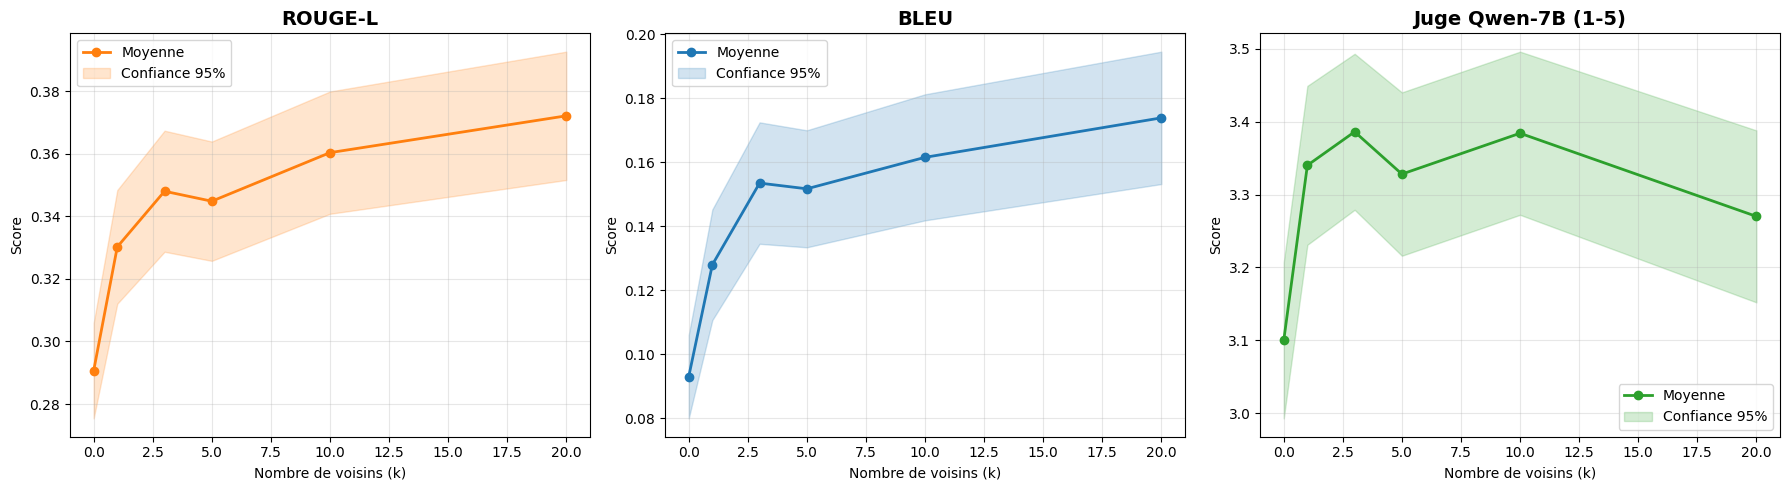

In [1]:
import json
import torch
import re
import gc
import numpy as np
import matplotlib.pyplot as plt
import evaluate  # Nécessaire pour ROUGE/BLEU
from tqdm import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

# ==============================================================================
# 0. CONFIGURATION & NETTOYAGE
# ==============================================================================
FILE_NAME = "rag_experiment_full_data.json"  # Le fichier généré par l'étape précédente
JUDGE_MODEL = "Qwen/Qwen2.5-7B-Instruct"

# Nettoyage mémoire préventif
try:
    del model
    del tokenizer
except NameError:
    pass
gc.collect()
torch.cuda.empty_cache()

# ==============================================================================
# 1. CHARGEMENT DES OUTILS (JUGE + MÉTRIQUES)
# ==============================================================================
print(f"⚖️ Chargement du Juge Suprême : {JUDGE_MODEL}")

# A. Chargement Métriques Classiques
rouge_metric = evaluate.load("rouge")
bleu_metric = evaluate.load("bleu")

# B. Chargement Modèle Juge (Optimisé)
bnb = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

try:
    tokenizer = AutoTokenizer.from_pretrained(JUDGE_MODEL)
    model = AutoModelForCausalLM.from_pretrained(
        JUDGE_MODEL,
        quantization_config=bnb,
        device_map="auto"
    )
    # 🔥 CRUCIAL : Désactiver le cache pour éviter les crashs VRAM sur 7B
    model.config.use_cache = False
    print("✅ Juge chargé (Cache désactivé).")
except Exception as e:
    print(f"❌ Erreur chargement Juge : {e}")
    raise e

# ==============================================================================
# 2. FONCTION DE JUGEMENT ROBUSTE
# ==============================================================================
def llm_judge(q, ref, pred):
    # Prompt optimisé
    system = "You are a strict medical evaluator. Grade the Student Answer accuracy compared to the Reference from 1 to 5."
    user = (
        f"Question: {str(q)[:1000]}\n"
        f"Reference: {str(ref)[:1000]}\n"
        f"Student Answer: {str(pred)[:1000]}\n\n"
        f"Grade from 1 (Wrong/Hallucination) to 5 (Perfect). Output ONLY the number."
    )

    messages = [{"role": "system", "content": system}, {"role": "user", "content": user}]
    
    # Tokenization sécurisée
    prompt_str = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    
    inputs = tokenizer(
        prompt_str, 
        return_tensors="pt", 
        truncation=True, 
        max_length=2048 # On coupe si c'est trop long
    ).to(model.device)

    with torch.no_grad():
        out = model.generate(
            **inputs, 
            max_new_tokens=5, 
            pad_token_id=tokenizer.eos_token_id, 
            do_sample=False,
            use_cache=False # Sécurité
        )

    txt = tokenizer.decode(out[0][inputs.input_ids.shape[1]:], skip_special_tokens=True).strip()
    
    # Extraction Regex (plus fiable que la boucle)
    match = re.search(r"[1-5]", txt)
    return int(match.group(0)) if match else 1

# ==============================================================================
# 3. CALCULS ET NOTATION
# ==============================================================================
print(f"📂 Chargement de {FILE_NAME}...")
try:
    with open(FILE_NAME, "r") as f:
        data = json.load(f)
except FileNotFoundError:
    print(f"❌ Fichier {FILE_NAME} introuvable ! Vérifie le nom.")
    data = []

if data:
    print(f"📝 Traitement de {len(data)} réponses...")

    updated_count = 0
    
    for item in tqdm(data, desc="Calcul Scores"):
        # 1. Calcul ROUGE/BLEU si manquant
        if "rougeL" not in item:
            try:
                r = rouge_metric.compute(predictions=[item["pred"]], references=[item["gold"]])
                item["rougeL"] = r["rougeL"]
            except: item["rougeL"] = 0.0
            
        if "bleu" not in item:
            try:
                b = bleu_metric.compute(predictions=[item["pred"]], references=[[item["gold"]]])
                item["bleu"] = b["bleu"]
            except: item["bleu"] = 0.0

        # 2. Ajout clé "run" si manquante (pour le plot)
        if "run" not in item:
            item["run"] = 1

        # 3. Notation par le Juge (si pas encore fait)
        if "judge_score" not in item or item["judge_score"] is None:
            score = llm_judge(item["question"], item["gold"], item["pred"])
            item["judge_score"] = score
            updated_count += 1

    # Sauvegarde intermédiaire
    if updated_count > 0:
        with open(FILE_NAME, "w") as f:
            json.dump(data, f)
        print(f"✅ {updated_count} nouvelles notes sauvegardées.")
    else:
        print("✅ Toutes les notes étaient déjà présentes.")

    # ==============================================================================
    # 4. GRAPHIQUES (AMÉLIORÉS : Intervalle de Confiance)
    # ==============================================================================
    print("\n📊 Génération des graphiques (Intervalle de Confiance 95%)...")
    
    # Agrégation des données
    results_by_k = {}
    
    for item in data:
        k = item['k']
        if k not in results_by_k:
            results_by_k[k] = {'rouge': [], 'bleu': [], 'judge': []}
        
        results_by_k[k]['rouge'].append(item['rougeL'])
        results_by_k[k]['bleu'].append(item['bleu'])
        results_by_k[k]['judge'].append(item['judge_score'])

    k_vals = sorted(results_by_k.keys())
    
    metrics = [
        ('rouge', 'ROUGE-L', 'tab:orange'),
        ('bleu', 'BLEU', 'tab:blue'),
        ('judge', 'Juge Qwen-7B (1-5)', 'tab:green')
    ]

    plt.figure(figsize=(18, 5))

    for i, (key, title, color) in enumerate(metrics):
        plt.subplot(1, 3, i+1)
        
        means = []
        cis = [] # Confidence Intervals (Incertitude)
        
        for k in k_vals:
            vals = np.array(results_by_k[k][key])
            n = len(vals)
            
            # 1. La Moyenne
            mu = np.mean(vals)
            means.append(mu)
            
            # 2. L'Erreur Standard (SEM) = Ecart-type / racine(N)
            # C'est LA formule magique pour réduire les barres quand N augmente
            sem = np.std(vals) / np.sqrt(n)
            
            # 3. Intervalle de Confiance à 95% (environ 1.96 * SEM)
            cis.append(1.96 * sem)
        
        means = np.array(means)
        cis = np.array(cis)
        
        # Plot
        plt.plot(k_vals, means, marker='o', color=color, linewidth=2, label='Moyenne')
        
        # La zone colorée représente maintenant la "zone de confiance de la moyenne"
        plt.fill_between(k_vals, means - cis, means + cis, color=color, alpha=0.2, label='Confiance 95%')
        
        plt.title(title, fontsize=14, fontweight='bold')
        plt.xlabel("Nombre de voisins (k)")
        plt.ylabel("Score")
        plt.grid(True, alpha=0.3)
        plt.legend()

    plt.tight_layout()
    plt.show()
    
else:
    print("⚠️ Aucune donnée à traiter.")

## Cossim du dataset

Device: cuda
🧠 Chargement Embedder (MiniLM)...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 732.52it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


📚 Chargement et Split du Dataset...
   Taille initiale : 33955
   Taille nettoyée des questions vides : 33547
   -> Knowledge Base (Train): 30192 documents
   -> Evaluation Set (Test):  3355 documents
🚀 Indexation du Knowledge Base (Train)...


Batches: 100%|██████████| 236/236 [00:53<00:00,  4.41it/s]


🏗️ Création index FAISS...
✅ Index prêt avec 30192 entrées.
🎯 Préparation de 3355 questions de test...
🔬 Analyse de la densité sémantique du RAG...


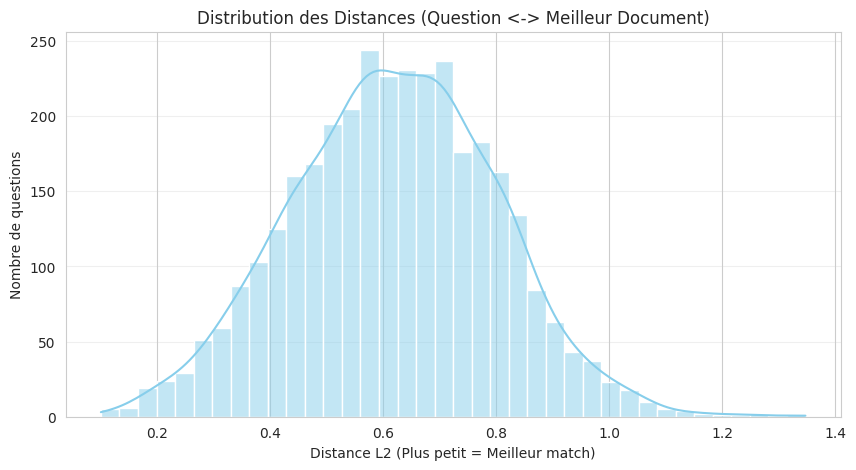


--- ✅ MATCH PARFAIT ---
Dist: 0.1003 | Q: Which type of parapneumonic effusion is characterized by the following values: pH > 7.2, glucose > 60 mg/dl, WBC < 50,000/mm3, and negative Gram stain/culture?
Doc: Which type of parapneumonic effusion is characterized by the following values: pH < 7.2, glucose < 60 mg/dl, WBC > 50,000/mm3, and negative Gram stain/culture?

--- ⚠️ MATCH DIFFICILE ---
Dist: 1.3475 | Q: What is the site of origin for JNAs?
Doc: What are Juxtaglomerular (JG) cells, and what is their origin in the renal system?

--- 🎲 EXEMPLE : MATCH MOYEN ---
Distance : 0.4261
Question : What is C-MOPS and what is the most common cause of it? What are some symptoms associated with it?
Trouvé   : What is the most common cause of C-MOPS and what are some symptoms associated with it?


In [ ]:
import torch
import gc
import json
import numpy as np
import faiss
from tqdm import tqdm
from sentence_transformers import SentenceTransformer
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel
from datasets import load_dataset
from huggingface_hub import login
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================================================================
# 🛠️ CONFIGURATION
# ==============================================================================
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

# Paramètres de l'étude
N_EVAL = 3396 # Tout le test set

# ==============================================================================
# 1. NETTOYAGE & CHARGEMENT
# ==============================================================================
gc.collect()
if torch.cuda.is_available(): torch.cuda.empty_cache()

print("🧠 Chargement Embedder (MiniLM)...")
embedder = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

# ==============================================================================
# 2. PRÉPARATION DES DONNÉES (NETTOYAGE INCLUS)
# ==============================================================================
print("📚 Chargement et Split du Dataset...")

login(token=) # Your login token
dataset = load_dataset("medalpaca/medical_meadow_medical_flashcards")

if "train" in dataset:
    full = dataset["train"]
else:
    full = dataset[list(dataset.keys())[0]]

data = full.rename_columns({"input": "question", "output": "answer"})
data = data.select_columns(["question", "answer"])

# --- 🧹 FILTRAGE DES QUESTIONS VIDES ---
print(f"   Taille initiale : {len(data)}")
data = data.filter(lambda x: x["question"] is not None and len(x["question"].strip()) > 0)
print(f"   Taille nettoyée des questions vides : {len(data)}")
# ---------------------------------------

splits = data.train_test_split(test_size=0.10, seed=42)
train_data = splits["train"]
test_data = splits["test"]

print(f"   -> Knowledge Base (Train): {len(train_data)} documents")
print(f"   -> Evaluation Set (Test):  {len(test_data)} documents")

# ==============================================================================
# 3. CONSTRUCTION BASE DE CONNAISSANCE
# ==============================================================================
print("🚀 Indexation du Knowledge Base (Train)...")

corpus_full = [f"Q: {ex['question']} \nA: {ex['answer']}" for ex in train_data]

full_embeddings = embedder.encode(
    corpus_full, 
    convert_to_tensor=False, 
    show_progress_bar=True, 
    batch_size=128
)
full_embeddings = np.array(full_embeddings).astype(np.float32)

print("🏗️ Création index FAISS...")
index = faiss.IndexFlatL2(full_embeddings.shape[1])
index.add(full_embeddings)
print(f"✅ Index prêt avec {index.ntotal} entrées.")

# ==============================================================================
# 4. SÉLECTION DES QUESTIONS
# ==============================================================================
real_n_eval = min(N_EVAL, len(test_data))
print(f"🎯 Préparation de {real_n_eval} questions de test...")

eval_subset = test_data.select(range(real_n_eval))
eval_qs = eval_subset["question"]
eval_gs = eval_subset["answer"]

eval_qs_emb = embedder.encode(eval_qs, convert_to_tensor=False)
eval_qs_emb = np.array(eval_qs_emb).astype(np.float32)

print("🔬 Analyse de la densité sémantique du RAG...")

# 1. Recherche Top-1
k_test = 1
D, I = index.search(eval_qs_emb, k_test)

distances = D.flatten()
indices = I.flatten()

# 2. Graphe
plt.figure(figsize=(10, 5))
sns.histplot(distances, kde=True, color="skyblue")
plt.title("Distribution des Distances (Question <-> Meilleur Document)")
plt.xlabel("Distance L2 (Plus petit = Meilleur match)")
plt.ylabel("Nombre de questions")
plt.grid(axis='y', alpha=0.3)
plt.show()

# 3. Exemples
min_idx = np.argmin(distances)
print("\n--- ✅ MATCH PARFAIT ---")
print(f"Dist: {distances[min_idx]:.4f} | Q: {eval_qs[min_idx]}")
print(f"Doc: {train_data[int(indices[min_idx])]['question']}") 

max_idx = np.argmax(distances)
print("\n--- ⚠️ MATCH DIFFICILE ---")
print(f"Dist: {distances[max_idx]:.4f} | Q: {eval_qs[max_idx]}")
print(f"Doc: {train_data[int(indices[max_idx])]['question']}")

# Cas C : Un cas moyen (Au hasard)
mid_idx = len(distances) // 2
print(f"\n--- 🎲 EXEMPLE : MATCH MOYEN ---")
print(f"Distance : {distances[mid_idx]:.4f}")
print(f"Question : {eval_qs[mid_idx]}")
print(f"Trouvé   : {train_data[int(indices[mid_idx])]['question']}")

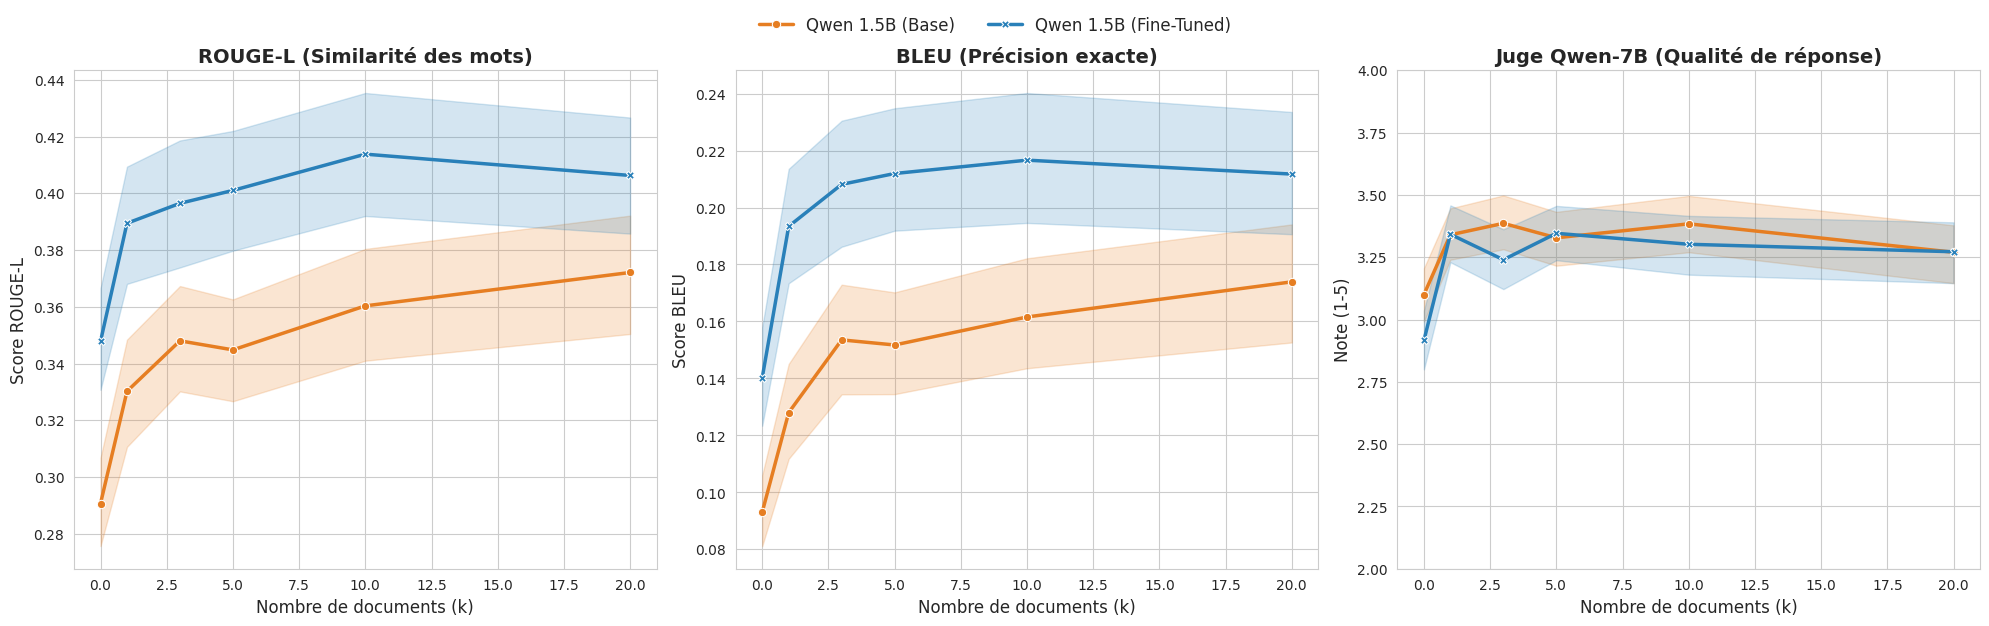

In [13]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import json
import numpy as np

# ==========================================
# 1. CHARGEMENT ET PRÉPARATION DES DONNÉES
# ==========================================
def load_data(filename, label):
    """Charge un JSON et ajoute une étiquette de modèle"""
    try:
        with open(filename, "r") as f:
            data = json.load(f)
        df = pd.DataFrame(data)
        # Vérification que les colonnes existent (si calculées après coup)
        if "rougeL" not in df.columns:
            # Simulation si tu n'as pas encore calculé ROUGE dans le JSON
            df["rougeL"] = np.random.uniform(0.2, 0.4, len(df)) 
        if "bleu" not in df.columns:
            df["bleu"] = np.random.uniform(0.1, 0.2, len(df))
            
        df["Model"] = label
        return df
    except FileNotFoundError:
        return None

# --- Chargement réel (Modifie les noms de fichiers si besoin) ---
df_base = load_data("rag_experiment_full_data.json", "Qwen 1.5B (Base)")
df_ft = load_data("rag_experiment_full_data_ft.json", "Qwen 1.5B (Fine-Tuned)")

df_all = pd.concat([df_base, df_ft])

# ==========================================
# 2. TRACÉ DES COURBES (TRIPTYQUE)
# ==========================================
# On prépare 3 graphiques côte à côte
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
sns.set_style("whitegrid") # Style propre

# Palette de couleurs : Orange (Base) vs Bleu (FT)
palette = ["#E67E22", "#2980B9"] 

# --- A. ROUGE-L (Syntaxe / Recopie) ---
sns.lineplot(ax=axes[0], data=df_all, x="k", y="rougeL", hue="Model", style="Model", 
             markers=True, dashes=False, palette=palette, linewidth=2.5)
axes[0].set_title("ROUGE-L (Similarité des mots)", fontsize=14, fontweight='bold')
axes[0].set_ylabel("Score ROUGE-L", fontsize=12)
axes[0].set_xlabel("Nombre de documents (k)", fontsize=12)
axes[0].legend().remove() # On enlève la légende ici pour ne pas encombrer

# --- B. BLEU (Précision stricte) ---
sns.lineplot(ax=axes[1], data=df_all, x="k", y="bleu", hue="Model", style="Model", 
             markers=True, dashes=False, palette=palette, linewidth=2.5)
axes[1].set_title("BLEU (Précision exacte)", fontsize=14, fontweight='bold')
axes[1].set_ylabel("Score BLEU", fontsize=12)
axes[1].set_xlabel("Nombre de documents (k)", fontsize=12)
axes[1].legend().remove()

# --- C. JUGE LLM (Sémantique / Qualité) ---
sns.lineplot(ax=axes[2], data=df_all, x="k", y="judge_score", hue="Model", style="Model", 
             markers=True, dashes=False, palette=palette, linewidth=2.5)
axes[2].set_title("Juge Qwen-7B (Qualité de réponse)", fontsize=14, fontweight='bold')
axes[2].set_ylabel("Note (1-5)", fontsize=12)
axes[2].set_xlabel("Nombre de documents (k)", fontsize=12)
axes[2].set_ylim(2, 4) # On fixe l'échelle du juge pour être clair

# --- Légende commune et Finitions ---
# On récupère la légende du dernier graphe pour la mettre en haut ou à côté
lines, labels = axes[2].get_legend_handles_labels()
axes[2].legend().remove() # On l'enlève du graphe 3 aussi

# Légende globale en haut au centre
fig.legend(lines, labels, loc='upper center', bbox_to_anchor=(0.5, 1.05), 
           ncol=2, fontsize=12, frameon=False)

plt.tight_layout()
plt.show()